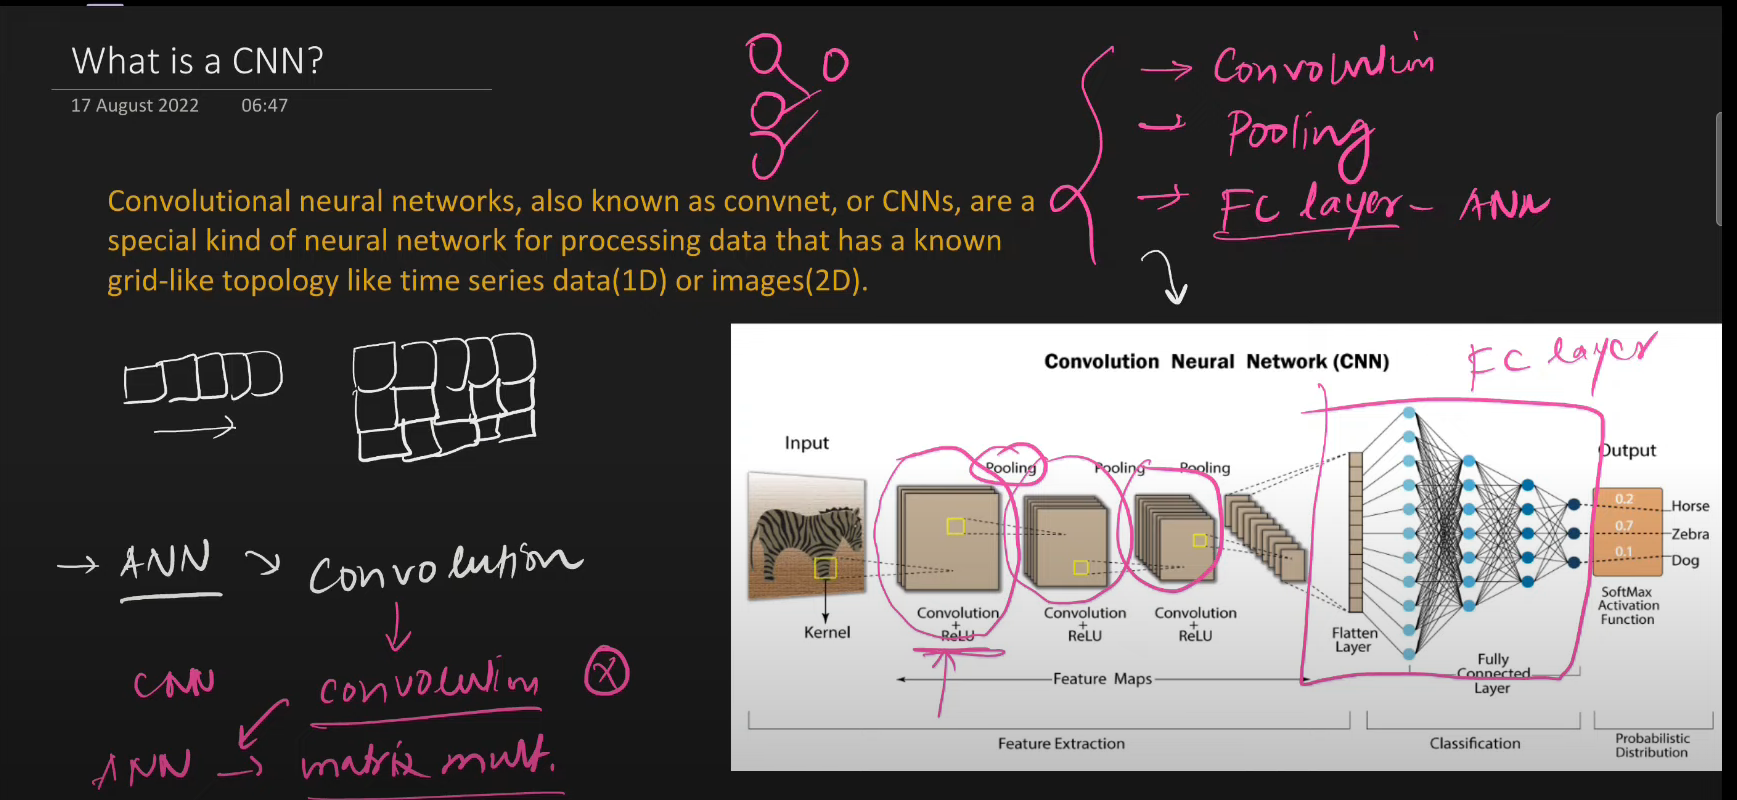

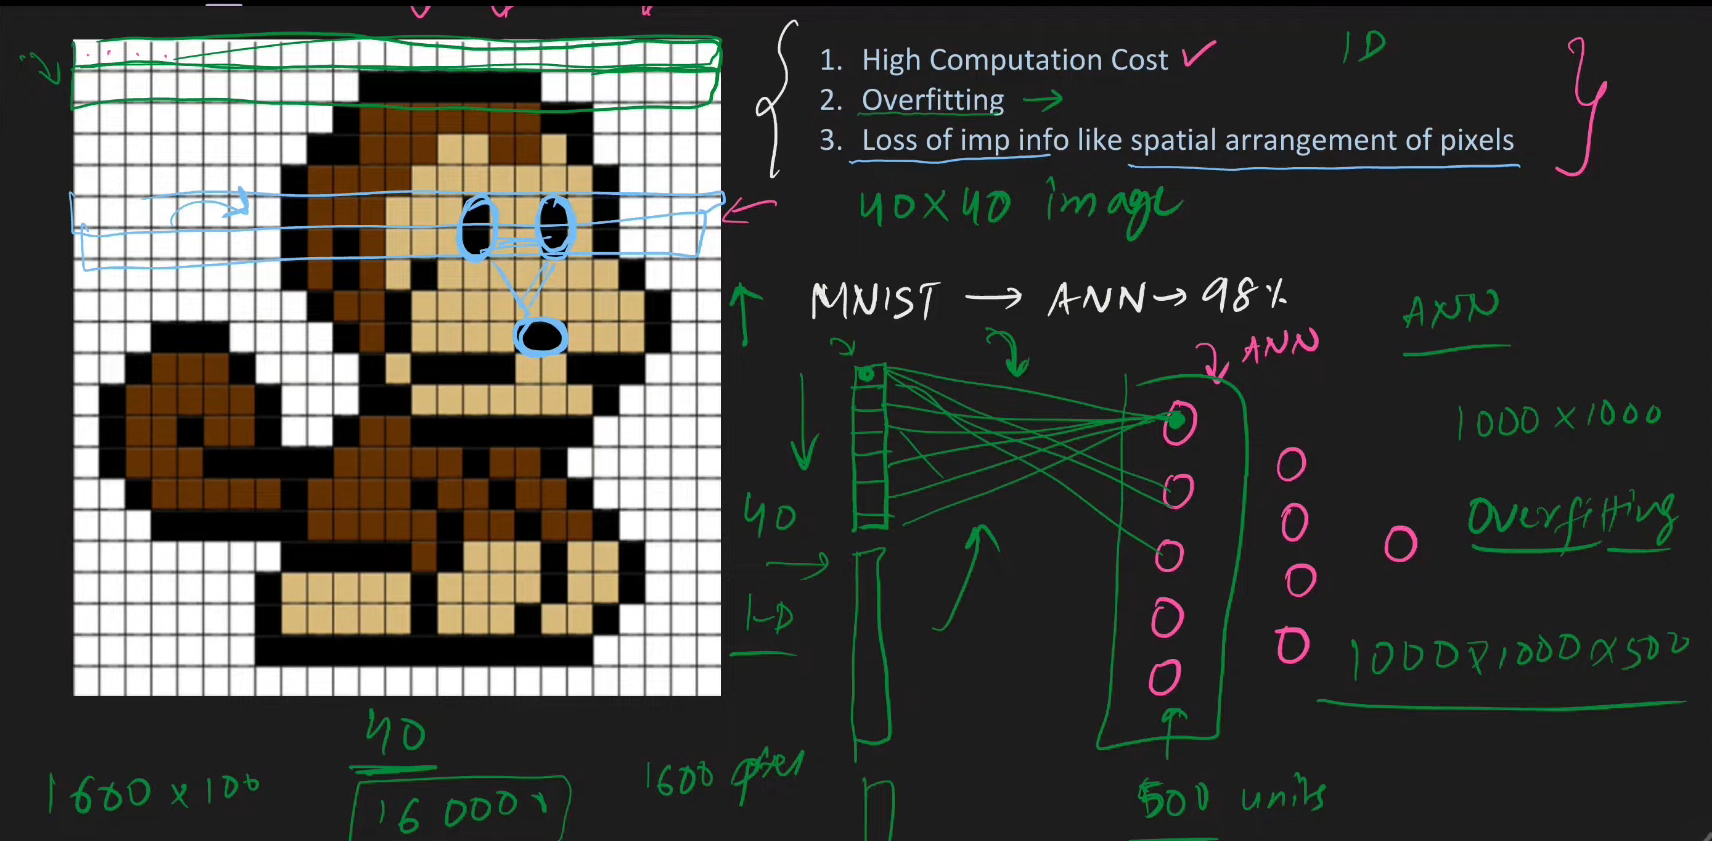

##Inspire
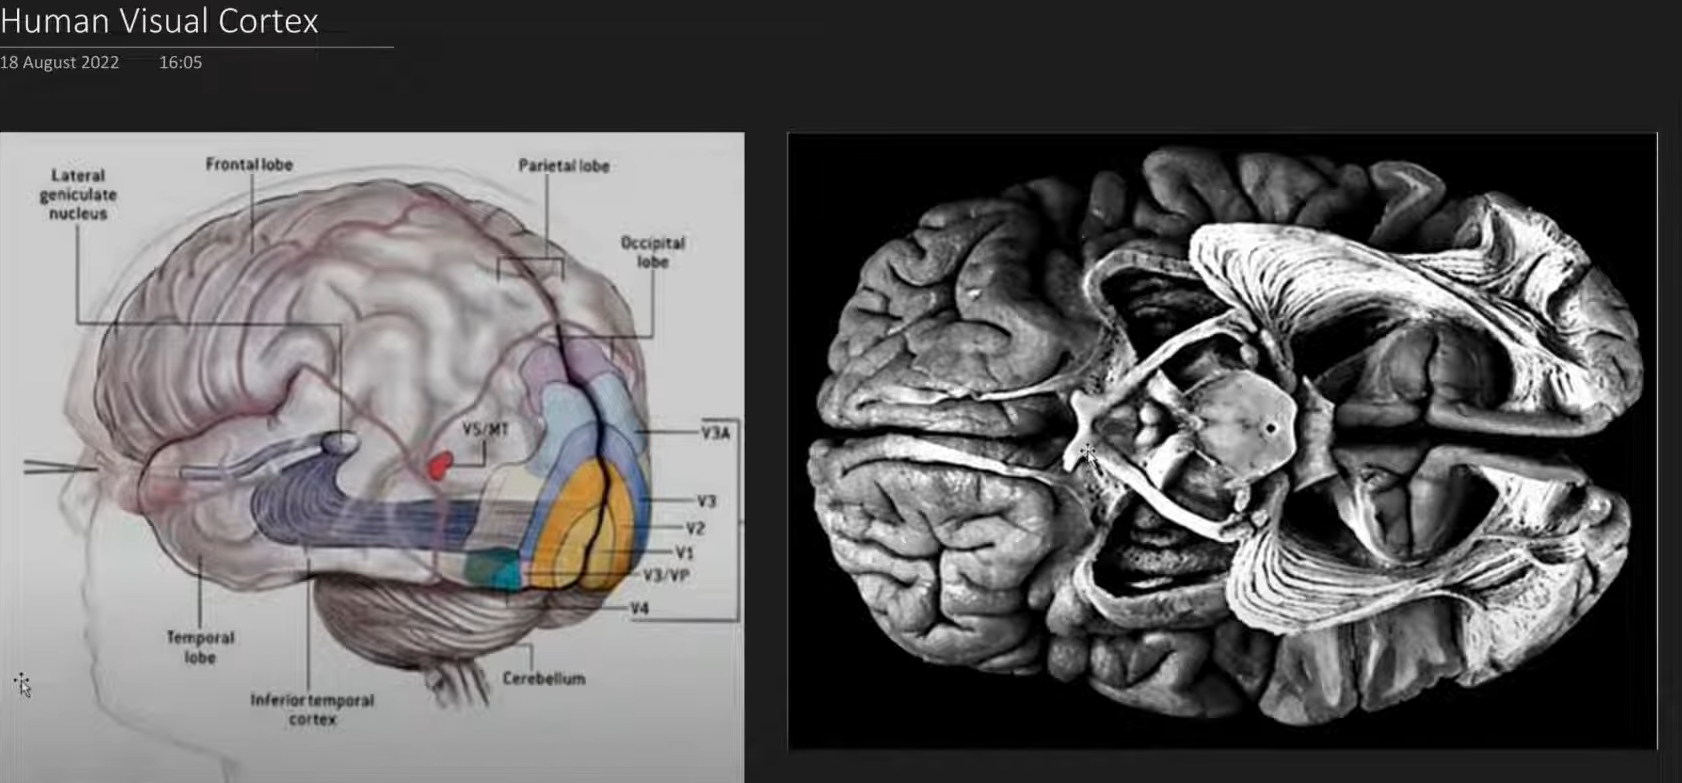

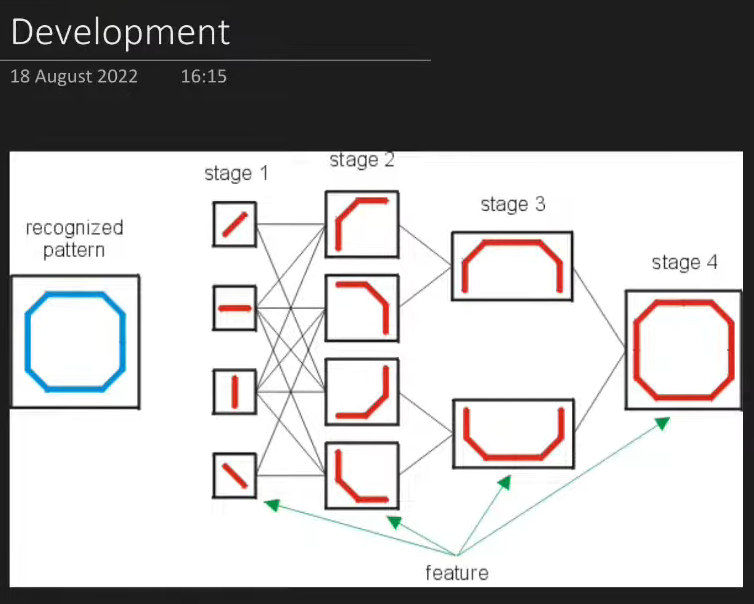



---

## 🧠 Convolutional Neural Network (CNN): Theory, Intuition, Math, and Comparison with ANN

---

### 1. **What is a CNN?**

A **Convolutional Neural Network (CNN)** is a type of deep neural network specifically designed to process **grid-like data**, such as images. It automatically learns **spatial hierarchies of features** — from edges and textures in early layers to complex patterns like faces or objects in deeper layers.

Unlike general-purpose neural networks, CNNs exploit the **local structure** of data by using **shared weights** and **local connectivity**.

---

### 2. **Why CNNs for Images? (Intuition)**

In an image:
- Nearby pixels are **highly correlated**.
- Patterns like edges, corners, and shapes are **local** — they appear in small regions.

A standard ANN treats an image as a flat vector (e.g., 28×28 → 784 values), losing spatial relationships. It also uses **fully connected layers**, meaning every neuron connects to every input — leading to:
- **Too many parameters**
- **Overfitting**
- **No translation invariance** (can't recognize an object if it moves)

A CNN fixes this by:
- **Preserving spatial structure** (2D arrangement)
- **Detecting local patterns** using filters
- **Sharing weights** across the image
- **Reducing spatial size** through pooling

This makes CNNs **efficient, robust, and effective** for vision tasks.

---

### 3. **Core Components of a CNN**

#### (a) **Convolutional Layer**

- Applies a **filter (kernel)** to the input.
- The filter slides (convolves) across the input, computing dot products.
- Each filter detects a specific **feature** (e.g., vertical edge, blur).

**Mathematical Definition:**

Let:
- Input: \( X \in \mathbb{R}^{H \times W \times C} \) (Height × Width × Channels)
- Filter: \( K \in \mathbb{R}^{F \times F \times C} \) (F × F × C)
- Output at position \( (i,j) \):  
  \[
  Y[i,j] = \sum_{a=0}^{F-1} \sum_{b=0}^{F-1} \sum_{c=0}^{C-1} X[i+a, j+b, c] \cdot K[a,b,c] + b
  \]
  where \( b \) is bias.

- Stride: step size of the filter (commonly 1 or 2).
- Padding: adds zeros around input to control output size.

**Output** is a **feature map** — highlighting where the filter's pattern occurs.

#### (b) **Activation Function (e.g., ReLU)**

After convolution, apply non-linearity:
\[
\text{ReLU}(x) = \max(0, x)
\]
This allows the network to learn non-linear mappings.

#### (c) **Pooling Layer (e.g., Max Pooling)**

Reduces spatial dimensions (downsampling), making the network:
- Computationally efficient
- Less sensitive to small shifts (translation invariance)

**Max Pooling Example:**
Divide feature map into 2×2 regions, take maximum:
\[
Y[i,j] = \max(X[2i:2i+2,\ 2j:2j+2])
\]

#### (d) **Fully Connected (Dense) Layers**

At the end, feature maps are flattened and passed through dense layers for classification — same as in ANNs.

---

### 4. **How CNN Works: Step-by-Step (Math Included)**

Suppose input is a **grayscale image**: \( 5 \times 5 \), single channel.

Apply a \( 3 \times 3 \) filter with stride 1, no padding:

\[
X = \begin{bmatrix}
1 & 2 & 3 & 2 & 1 \\
2 & 4 & 6 & 4 & 2 \\
3 & 6 & 9 & 6 & 3 \\
2 & 4 & 6 & 4 & 2 \\
1 & 2 & 3 & 2 & 1 \\
\end{bmatrix},\quad
K = \begin{bmatrix}
1 & 0 & -1 \\
1 & 0 & -1 \\
1 & 0 & -1 \\
\end{bmatrix}
\]

Convolution at top-left:
\[
Y[0,0] = (1)(1) + (2)(0) + (3)(-1) + (2)(1) + (4)(0) + (6)(-1) + (3)(1) + (6)(0) + (9)(-1) = 1 - 3 + 2 - 6 + 3 - 9 = -12
\]

Repeat across image → get a \( 3 \times 3 \) feature map.

Add ReLU → set negatives to 0.

Apply max pooling (2×2, stride 2) → reduce to \( 1 \times 1 \) per region.

Final feature maps are flattened and fed to dense layers.

---

### 5. **Key Differences Between CNN and ANN**

| Feature | ANN (Fully Connected Network) | CNN |
|--------|-------------------------------|-----|
| **Input Structure** | Flattened vector (loses 2D structure) | Preserves 2D/3D structure |
| **Connectivity** | Every neuron connected to all inputs (dense) | Local connectivity (each neuron sees only a small region) |
| **Weight Sharing** | No — each connection has unique weight | Yes — same filter used across entire image |
| **Parameters** | Very high (e.g., 784×128 = 100k+ for MNIST) | Much lower due to shared weights |
| **Translation Invariance** | Poor — same object in different location may not be recognized | Good — pooling and shared filters help detect objects anywhere |
| **Spatial Hierarchy** | No — treats all pixels equally | Yes — learns edges → shapes → objects |
| **Use Case** | Small, structured data (e.g., tabular) | Grid-like data (images, audio spectrograms) |

---

### 6. **Why CNNs Outperform ANNs on Images**

1. **Parameter Efficiency**:  
   A CNN with 32 filters of size \( 3\times3 \) on a \( 28\times28 \) image uses only \( 32 \times (3\times3 + 1) = 320 \) parameters per layer (including bias).  
   An ANN layer with 128 neurons uses \( 784 \times 128 = 100,352 \) parameters.

2. **Local Receptive Fields**:  
   Neurons in early layers respond to small regions — mimicking biological vision.

3. **Hierarchical Feature Learning**:  
   - Layer 1: Detects edges and blobs  
   - Layer 2: Combines edges into shapes  
   - Layer 3: Recognizes object parts  
   - Final layers: Classify whole objects

4. **Translation Equivariance**:  
   If input shifts, the feature map shifts accordingly — pooling then provides invariance.

---

### 7. **Summary**

- A **CNN** processes data with **grid topology** (like images) using **convolutional layers** that apply **learnable filters**.
- It uses **local connectivity** and **weight sharing** to drastically reduce parameters and improve generalization.
- **Pooling** reduces spatial size and adds robustness.
- The learned features are **hierarchical** and **spatially aware**.
- Unlike **ANNs**, which treat inputs as unordered vectors, **CNNs preserve and exploit spatial structure**.

> In short:  
> **ANNs** are general function approximators.  
> **CNNs** are specialized for **spatial data**, making them vastly more effective for vision.

---


In [1]:
import tensorflow as tf

# Load and preprocess
(x_train, y_train), _ = tf.keras.datasets.mnist.load_data()
x_train = x_train.reshape(-1, 28, 28, 1).astype('float32') / 255.0
y_train = tf.keras.utils.to_categorical(y_train, 10)

# Model
model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(16, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(10, activation='softmax')
])

# Compile and train
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.fit(x_train, y_train, epochs=1, batch_size=32, verbose=1)

print("TensorFlow CNN training complete.")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 33s 16ms/step - accuracy: 0.8780 - loss: 0.4496
TensorFlow CNN training complete.
